In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2 as cv
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import random
from tensorflow.keras import backend as K
import gc
import re

# 清理記憶體
def MODEL_GC(model):
    del model
    K.clear_session()
    gc.collect()

In [2]:
train_dir = "C:/YvesProject/中央/AI作業/train_resized/"
test_dir = "C:/YvesProject/中央/AI作業/test_resized/"
artists = pd.read_csv("C:/YvesProject/中央/AI作業/artists.csv")
num_classes = artists.shape[0]
print("Number of artists : ", num_classes)
artists.head()

Number of artists :  50


,id,name,years,genre,nationality,bio,wikipedia,paintings
0,0,Amedeo Modigliani,1884 - 1920,Expressionism,Italian,Amedeo Clemente Modigliani (Italian pronunciat...,http://en.wikipedia.org/wiki/Amedeo_Modigliani,193
1,1,Vasiliy Kandinskiy,1866 - 1944,"Expressionism,Abstractionism",Russian,Wassily Wassilyevich Kandinsky (Russian: ?а?и?...,http://en.wikipedia.org/wiki/Wassily_Kandinsky,88
2,2,Diego Rivera,1886 - 1957,"Social Realism,Muralism",Mexican,Diego María de la Concepción Juan Nepomuceno E...,http://en.wikipedia.org/wiki/Diego_Rivera,70
3,3,Claude Monet,1840 - 1926,Impressionism,French,Oscar-Claude Monet (; French: [klod m?n?]; 14 ...,http://en.wikipedia.org/wiki/Claude_Monet,73
4,4,Rene Magritte,1898 - 1967,"Surrealism,Impressionism",Belgian,René François Ghislain Magritte (French: [??ne...,http://en.wikipedia.org/wiki/René_Magritte,194


In [3]:
### 只取出名字與畫的數量，把名字用下底線連起來
artists = artists.loc[:, ["name", "paintings"]]
artists["name"] = artists["name"].str.split(" ").apply(lambda parts: "_".join(parts))
artists.head()

,name,paintings
0,Amedeo_Modigliani,193
1,Vasiliy_Kandinskiy,88
2,Diego_Rivera,70
3,Claude_Monet,73
4,Rene_Magritte,194


可以看到每個畫家之間的畫作數量很不平均，這會影響到模型的訓練。
最多畫作為 :  877  最少畫作為 :  24
畫作數量的平均值為 :  168.92


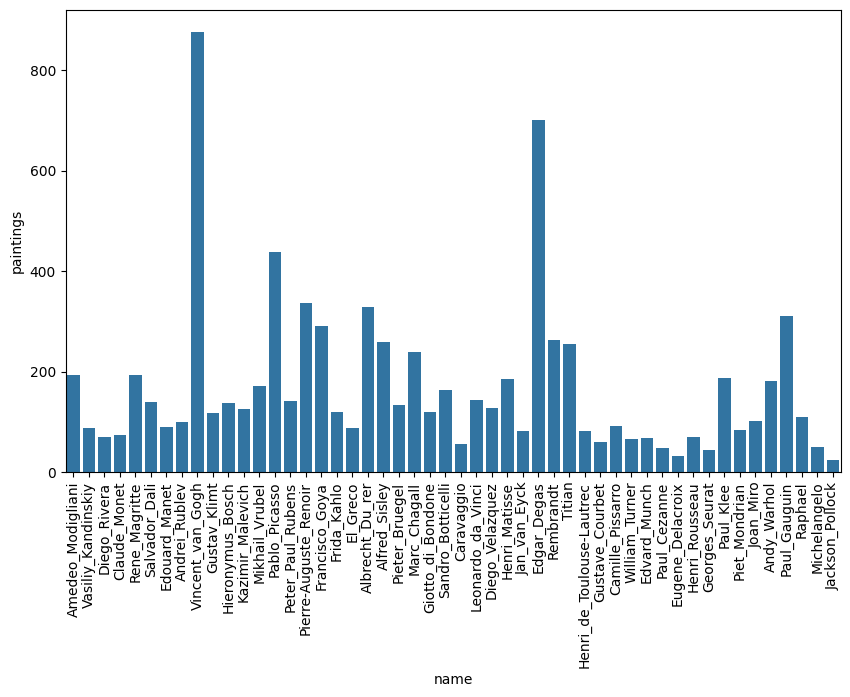

In [4]:
%matplotlib inline
plt.figure(figsize=(10, 6))
barplot = sns.barplot(x="name", y="paintings",data=artists)
for item in barplot.get_xticklabels():
    item.set_rotation(90)

avg_paint = artists.paintings.mean()

print("可以看到每個畫家之間的畫作數量很不平均，這會影響到模型的訓練。")
print("最多畫作為 : ", artists.paintings.max(), " 最少畫作為 : ", artists.paintings.min())
print("畫作數量的平均值為 : ", avg_paint)

In [5]:
from PIL import Image

# 確保 train_dir 中有圖片
img_list = os.listdir(train_dir)  # List all files in the directory

# 顯示圖片數量
total_len = len(img_list)
print("training 畫作總共畫作有 : ", total_len)

# 隨機選取 20 張圖片
random_list = random.sample(range(0, total_len), 20)

show_imgs = [img_list[rand] for rand in random_list]

'''plt.figure(figsize=(16, 16))
for index, imgName in enumerate(show_imgs):
    img_path = os.path.join(train_dir, imgName)

    try:
        img = Image.open(img_path)
        img = np.array(img)  # 將 PIL 圖片轉換為 NumPy 陣列
        img = cv.cvtColor(img, cv.COLOR_RGB2BGR)  # 轉換為 OpenCV 格式
    except Exception as e:
        print(f"無法讀取圖檔 {img_path}，錯誤訊息: {e}")
        continue
        
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    plt.subplot(4, 5, index + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("_".join(imgName.split("_")[:-1]))'''

training 畫作總共畫作有 :  7520


'plt.figure(figsize=(16, 16))\nfor index, imgName in enumerate(show_imgs):\n    img_path = os.path.join(train_dir, imgName)\n\n    try:\n        img = Image.open(img_path)\n        img = np.array(img)  # 將 PIL 圖片轉換為 NumPy 陣列\n        img = cv.cvtColor(img, cv.COLOR_RGB2BGR)  # 轉換為 OpenCV 格式\n    except Exception as e:\n        print(f"無法讀取圖檔 {img_path}，錯誤訊息: {e}")\n        continue\n        \n    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)\n    plt.subplot(4, 5, index + 1)\n    plt.imshow(img)\n    plt.axis("off")\n    plt.title("_".join(imgName.split("_")[:-1]))'

In [6]:
# 移除檔名中的 "_數字.jpg" 部分
def remove_number_from_filename(filename):
    return re.sub(r'_\d+\.jpg$', '', filename)

def make_author_dict(train_dir):
    # 取得所有圖片檔案名稱
    img_list = os.listdir(train_dir)
    
    # 使用 remove_number_from_filename 函式處理檔名，去掉數字和檔案後綴
    author_list = sorted(set([remove_number_from_filename(img) for img in img_list]))  # 去掉 _後的數字部分並排序
    author_dict = {author: idx for idx, author in enumerate(author_list)}  # 映射作者名稱到數字
    return author_dict

# 創建作者名稱到數字的映射
class_name = make_author_dict(train_dir)

# 創建數字到作者名稱的反向映射
rev_class_name = {v: k for k, v in class_name.items()}

# 測試
print("作者名稱到數字映射:", class_name)
print("數字到作者名稱映射:", rev_class_name)

作者名稱到數字映射: {'Albrecht_Du_rer': 0, 'Alfred_Sisley': 1, 'Amedeo_Modigliani': 2, 'Andrei_Rublev': 3, 'Andy_Warhol': 4, 'Camille_Pissarro': 5, 'Caravaggio': 6, 'Claude_Monet': 7, 'Diego_Rivera': 8, 'Diego_Velazquez': 9, 'Edgar_Degas': 10, 'Edouard_Manet': 11, 'Edvard_Munch': 12, 'El_Greco': 13, 'Eugene_Delacroix': 14, 'Francisco_Goya': 15, 'Frida_Kahlo': 16, 'Georges_Seurat': 17, 'Giotto_di_Bondone': 18, 'Gustav_Klimt': 19, 'Gustave_Courbet': 20, 'Henri_Matisse': 21, 'Henri_Rousseau': 22, 'Henri_de_Toulouse-Lautrec': 23, 'Hieronymus_Bosch': 24, 'Jackson_Pollock': 25, 'Jan_van_Eyck': 26, 'Joan_Miro': 27, 'Kazimir_Malevich': 28, 'Leonardo_da_Vinci': 29, 'Marc_Chagall': 30, 'Michelangelo': 31, 'Mikhail_Vrubel': 32, 'Pablo_Picasso': 33, 'Paul_Cezanne': 34, 'Paul_Gauguin': 35, 'Paul_Klee': 36, 'Peter_Paul_Rubens': 37, 'Pierre-Auguste_Renoir': 38, 'Piet_Mondrian': 39, 'Pieter_Bruegel': 40, 'Raphael': 41, 'Rembrandt': 42, 'Rene_Magritte': 43, 'Salvador_Dali': 44, 'Sandro_Botticelli': 45, 'Titian'

In [7]:
### 此為數據增強區塊
from tensorflow.keras.layers.experimental import preprocessing

# 定義數據增強
data_augmentation = tf.keras.Sequential([
    preprocessing.RandomFlip("horizontal_and_vertical"),  # 隨機水平和垂直翻轉
    preprocessing.RandomRotation(0.25),                    # 隨機旋轉
    preprocessing.RandomZoom(0.2),                         # 隨機縮放
    preprocessing.RandomTranslation(0.3, 0.2),             # 隨機平移（橫向 30%，縱向 20%）
    preprocessing.RandomContrast(0.2),                     # 隨機對比度變化
])

# 高斯噪聲增強 噪聲影響程度較強
def add_gaussian_noise(image, mean=0.0, stddev=1.0):
    noise = tf.random.normal(shape=tf.shape(image), mean=mean, stddev=stddev)
    return tf.add(image, noise)

# 隨機噪聲 噪聲影響程較溫和
def add_random_noise(image):
    # 增加模型抗干擾的能力（例如圖片有點模糊、有點雜訊也能認出來）
    # 避免 overfitting：因為每張圖可能都有不同的噪聲變化
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.05, dtype=tf.float32)
    image = image + noise
    return tf.clip_by_value(image, 0.0, 1.0)

# 色彩變化增強
def add_color_jitter(image):
    image = tf.image.random_hue(image, max_delta=0.1)  # 隨機改變色調
    image = tf.image.random_saturation(image, lower=0.5, upper=1.5)  # 隨機改變飽和度
    image = tf.image.random_contrast(image, lower=0.5, upper=1.5)  # 隨機對比度變化
    return image

# 高斯模糊
def add_gaussian_blur(image, blur_strength=2.0):
    return tf.image.adjust_contrast(image, 1.0 + blur_strength)

# 更新 data augmentation，增加新的增強操作
def data_augmentation_with_noise(image):
    # 原始增強操作
    image = data_augmentation(image)
    # 加入噪聲
    image = add_gaussian_noise(image)
    # 加入色彩變化
    image = add_color_jitter(image)
    # 加入高斯模糊
    image = add_gaussian_blur(image)
    return image

In [8]:
### 此為過採樣區塊
def oversample_dataset(data, label_counts, min_class_size, oversample_factor=2):
    """
    進行過採樣，增加少數類別的樣本。

    data: [(path, one_hot_label), ...]
    label_counts: {class_index: count}
    min_class_size: 最少樣本數量的畫家所需達到的大小
    oversample_factor: 增加少數類別樣本的倍數
    """
    oversampled_data = []

    for path, label in data:
        class_index = np.argmax(label)  # 將 one-hot label 轉回 index
        label_size = label_counts[class_index]

        if label_size < min_class_size:
            for _ in range(oversample_factor):
                oversampled_data.append((path, label))
        else:
            oversampled_data.append((path, label))

    # 打散資料
    random.shuffle(oversampled_data)

    # 拆開成 paths, labels
    paths, labels = zip(*oversampled_data)
    return list(paths), list(labels)

In [9]:
# 取得圖像標籤並轉成數字
def get_label(pic_name, class_name):
    # 取得作者名稱（去掉數字和後綴）
    author_name = remove_number_from_filename(pic_name)
    
    # 將作者名稱轉換為對應的數字標籤
    label = class_name.get(author_name, -1)  # 若找不到作者，返回 -1 (表示錯誤)
    
    return label

# 合併路徑
def get_path(dir, pic_name):
    return os.path.join(dir, pic_name)

# 生成圖片路徑和標籤
def make_paths_label(dir, class_name):
    img_list = os.listdir(dir)
    paths = []
    labels = []

    # 遍歷所有圖片檔案
    for img_name in img_list:
        # 取得圖片的完整路徑
        path = get_path(dir, img_name)
        paths.append(path)
        
        # 取得對應的標籤（數字）
        label = get_label(img_name, class_name)
        labels.append(label)

    # 將 labels 轉換為 one-hot 編碼
    onehot_labels = np.zeros((len(labels), len(class_name)))
    for idx, label in enumerate(labels):
        if label != -1:
            onehot_labels[idx, label] = 1  # 將對應的索引設為 1

    return paths, onehot_labels

# 將圖片路徑與標籤，變成 TensorFlow 可訓練的 Dataset
def create_dataset_from_raw(paths, labels, author_to_index, img_size=(256, 256), augment=False, shuffle=False, batch_size=32):
    # step 1: 整理出畫作數量統計資訊
    label_to_author = {i: name for name, i in author_to_index.items()}
    author_counts = pd.Series([label_to_author[np.argmax(label)] for label in labels]).value_counts()
    avg_paint = int(author_counts.mean())

    # step 2: 建立作者名稱與少數樣本對應表
    minority_authors = set(author_counts[author_counts < avg_paint].index)

    # step 3: 為每個 path 標註是否屬於少數樣本
    path_is_minority = {}
    for path, label in zip(paths, labels):
        filename = os.path.basename(path)
        author_name = remove_number_from_filename(filename)
        path_is_minority[path] = author_name in minority_authors

    # step 4: 轉成 list 並建立 minority 標記
    minority_flags = [path_is_minority[p] for p in paths]

    # step 5: 建立 dataset，包含 minority 標記
    dataset = tf.data.Dataset.from_tensor_slices((list(paths), np.array(labels), np.array(minority_flags)))

    # step 6: 圖像預處理與增強邏輯
    # 更新 map_fn，返回圖片數據，而不是路徑
    def map_fn(x, y, is_minor):
        img = tf.io.read_file(x)  # 讀取圖片
        img = tf.image.decode_jpeg(img, channels=3)  # 解碼為 RGB 圖片
        img = tf.image.resize(img, img_size)  # 縮放圖片
        img = tf.cast(img, tf.float32) / 255.0  # 正規化至 [0, 1]
        
        if augment:
            img = data_augmentation_with_noise(img)  # 圖片增強
            if is_minor:
                img = add_random_noise(img)  # 少數類別增強
            img = tf.clip_by_value(img, 0.0, 1.0)  # 保證圖片數據在有效範圍
    
        # 轉換標籤為 float32 類型
        y = tf.cast(y, tf.float32)
        
        return img, y  # 返回圖片和標籤

    # step 7: 應用 map
    dataset = dataset.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(paths))

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [10]:
# 設定圖片大小和打散緩衝區大小
IMG_WIDTH = 1024  # 設定圖片寬度
IMG_HEIGHT = 1024  # 
SHUFFLE_BUFFER = 1000  # 設定打散緩衝區大小
BATCH_SIZE = 32  # 設定批次大小
MODEL_WIDTH = 256  # 設定模型採用的寬度
MODEL_HEIGHT = 256  # 設定模型採用的高度設定圖片高度
MODEL_IMG_SIZE = (MODEL_WIDTH, MODEL_HEIGHT)  # 圖片大小

# Step 1: 拿到所有路徑和標籤
paths, labels = make_paths_label(train_dir, class_name)

# Step 2: 過採樣少數類別畫家  以平均值作為過採樣門檻
label_counts = {}  # 計算每個畫家類別的樣本數
for label in labels:
    label = np.argmax(label)  # 轉回類別 index
    label_counts[label] = label_counts.get(label, 0) + 1

# 設定過採樣門檻 (例如以平均數作為門檻)
#avg_paint = sum(label_counts.values()) / len(label_counts)
#paths, labels = oversample_dataset(list(zip(paths, labels)), label_counts, min_class_size=avg_paint, oversample_factor=2)

# Step 3: 打散
combined = list(zip(paths, labels))
random.shuffle(combined)
paths, labels = zip(*combined)

# Step 4: 分割
split_index = int(0.8 * len(paths))
train_paths, val_paths = paths[:split_index], paths[split_index:]
train_labels, val_labels = labels[:split_index], labels[split_index:]

# Step 5: 分別創建資料集
train_ds = create_dataset_from_raw(train_paths, train_labels, class_name, img_size=MODEL_IMG_SIZE, augment=False)
val_ds = create_dataset_from_raw(val_paths, val_labels, class_name, img_size=MODEL_IMG_SIZE, augment=False)

# 這裡可以進一步增加預取功能來加速訓練
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

# 查看資料集中的部分資料
for image, label in train_ds.take(1):
    print(f"Image type: {image.dtype}, Label type: {label.dtype}")
    print(f"Image shape: {image.shape}, Label shape: {label.shape}")

Image type: <dtype: 'float32'>, Label type: <dtype: 'float32'>
Image shape: (32, 256, 256, 3), Label shape: (32, 50)


In [11]:
###4. 定義CNN層
from tensorflow.keras import layers, models, regularizers

input_shape = (MODEL_WIDTH, MODEL_HEIGHT, 3)
CNN_layers = [
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
]

# 我原來的
def create_model_0(input_shape, num_classes):
    model = models.Sequential(CNN_layers)
    return model

# 輕量級CNN結構
def create_model_1(input_shape, num_classes):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.4))

    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

# 深層次的卷積網絡
def create_model_2(input_shape, num_classes):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(num_classes, activation='softmax'))
    return model
    
# 較大卷積核的網絡 卷積核 (5x5)，這能夠在較大的範圍內捕捉特徵
def create_model_3(input_shape, num_classes):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    model.add(layers.Conv2D(32, (5, 5), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (5, 5), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    
    model.add(layers.Conv2D(128, (5, 5), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

# 深層卷積網絡，增加L2正則化
def create_model_4(input_shape, num_classes):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.MaxPooling2D((2, 2)))
    
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

# 增加跳躍連接（Residual Connections）
def create_model_5(input_shape, num_classes):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(model.input)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    skip = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    skip = layers.MaxPooling2D((2, 2))(skip)

    # 調整 skip 的尺寸，與 x 進行匹配
    skip = layers.UpSampling2D(size=(2, 2))(skip)  # 上採樣
    skip = layers.Conv2D(64, (1, 1), activation='relu', padding='same')(skip)  # 調整通道數

    # 進行跳躍連接
    x = layers.Add()([x, skip])  # 跳躍連接
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs=model.input, outputs=x)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import LearningRateScheduler

# EarlyStopping：在 val_loss 超過 5 個 epoch 沒有進步時停止訓練，並恢復最佳權重
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau：當 val_loss 超過 3 個 epoch 沒進步時，將學習率乘以 factor
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# 定義學習率調整函數
def lr_schedule(epoch, lr):
    if epoch < 10:
        return lr  # 在前 10 個 epoch 中，保持初始學習率不變
    else:
        return lr * tf.math.exp(-0.1)  # 每 10 個 epoch 學習率衰減

# LearningRateScheduler：動態調整學習率
learning_rate_scheduler = LearningRateScheduler(lr_schedule, verbose=1)

# Step 1: 計算每個類別的索引
label_indices = np.argmax(labels, axis=1)

# Step 2: 計算每個類別的權重
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(label_indices),
    y=label_indices
)

# Step 3: 根據數量差異來手動調整權重
weights_adjusted = []
for i, weight in enumerate(weights):
    adjusted_weight = weight * (label_counts.get(i, 1) / sum(label_counts.values()))
    weights_adjusted.append(adjusted_weight)

# Step 4: 生成調整後的權重字典
class_weights_dict = {i: weight for i, weight in enumerate(weights_adjusted)}

print("調整後的類別權重:", class_weights_dict)

調整後的類別權重: {0: 0.02, 1: 0.02, 2: 0.02, 3: 0.02, 4: 0.02, 5: 0.02, 6: 0.02, 7: 0.02, 8: 0.02, 9: 0.02, 10: 0.019999999999999997, 11: 0.02, 12: 0.02, 13: 0.019999999999999997, 14: 0.02, 15: 0.02, 16: 0.02, 17: 0.019999999999999997, 18: 0.019999999999999997, 19: 0.02, 20: 0.02, 21: 0.02, 22: 0.02, 23: 0.02, 24: 0.019999999999999997, 25: 0.019999999999999997, 26: 0.019999999999999997, 27: 0.019999999999999997, 28: 0.02, 29: 0.02, 30: 0.02, 31: 0.02, 32: 0.019999999999999997, 33: 0.02, 34: 0.02, 35: 0.019999999999999997, 36: 0.02, 37: 0.02, 38: 0.02, 39: 0.02, 40: 0.02, 41: 0.02, 42: 0.019999999999999997, 43: 0.02, 44: 0.020000000000000004, 45: 0.02, 46: 0.019999999999999997, 47: 0.019999999999999997, 48: 0.02, 49: 0.02}


In [13]:
###4.&5. 建立模型&制定計畫
### 多模型訓練
EPOCHS = 200
NUM_MODELS = 2  # 要訓練幾個模型
opti = tf.keras.optimizers.RMSprop(momentum=0.1) 
best_acc_path = "C:/YvesProject/中央/AI作業/best_accuracy.txt"
#model_save_path = "C:/YvesProject/中央/AI作業/best_model.h5"
ensemble_model_save_path = "C:/YvesProject/中央/AI作業/"
models_arr = []

# 用來記錄每個模型的最佳驗證準確率 根據後續訓練的結果動態設定各模型的初始權重
model_accuracies = {model_idx: 0 for model_idx in range(NUM_MODELS)}

# 定義一個模型字典，用於選擇對應的模型架構
model_functions = {
    0: create_model_0,
    1: create_model_1,
    #2: create_model_2,
    #3: create_model_3,
    #4: create_model_4,
    #5: create_model_5
}

for model_idx in range(NUM_MODELS):
#for model_idx in [0]:
    print(f"\n🔁 Training model {model_idx + 1}/{NUM_MODELS}")
    
    # 建立新模型
    # 使用字典選擇對應的模型結構
    model = model_functions[model_idx](input_shape, num_classes)
    model.compile(
        optimizer=opti,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # 使用 EarlyStopping + ReduceLROnPlateau
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[early_stopping, reduce_lr, learning_rate_scheduler],
        class_weight=class_weights_dict
    )

    # 記錄該模型在驗證集上的最佳準確率
    best_val_accuracy = max(history.history['val_accuracy'])
    model_accuracies[model_idx] = best_val_accuracy
    models_arr.append(model)

    # 清理 GPU 記憶體
    MODEL_GC(model)

# 動態計算模型權重
total_accuracy = sum(model_accuracies.values())  # 計算總準確率
model_weights = {model_idx: accuracy / total_accuracy for model_idx, accuracy in model_accuracies.items()}

# 顯示每個模型的權重
print("\nDynamic model weights based on validation accuracy:")
print(model_weights)


🔁 Training model 1/2

Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/200
188/188 [==============================] - 9s 32ms/step - loss: 0.0731 - accuracy: 0.1105 - val_loss: 3.5587 - val_accuracy: 0.1250 - lr: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 2/200
188/188 [==============================] - 6s 31ms/step - loss: 0.0689 - accuracy: 0.1529 - val_loss: 3.3652 - val_accuracy: 0.1742 - lr: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 3/200
188/188 [==============================] - 6s 31ms/step - loss: 0.0659 - accuracy: 0.1813 - val_loss: 3.2622 - val_accuracy: 0.1941 - lr: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 4/200
188/188 [==============================] - 6s 33ms/step - loss: 0.0629 - accuracy: 0.2040 - val_loss: 3.1965 - val_accuracy: 0.1862 - lr: 0.0010

Epoch 5: LearningRateSchedule

In [14]:
### 權重投票
def predict_with_weighted_voting(models, X, model_weights):
    predictions = np.array([model.predict(X) for model in models])
    weighted_predictions = np.average(predictions, axis=0, weights=[model_weights[model.name] for model in models])
    
    return weighted_predictions

In [15]:
### 投票機制
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score

# 重新產生測試資料集
test_paths, test_labels = make_paths_label(test_dir, class_name)
test_ds = create_dataset_from_raw(test_paths, test_labels, class_name, img_size=MODEL_IMG_SIZE, augment=False, shuffle=False, batch_size=32)
#test_ds = create_dataset(test_dir, class_name) 
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# 真實標籤
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

# 進行預測投票
predictions = []

# 進行預測並收集每個模型的預測結果
for tmp_idx, tmp_model in enumerate(models_arr):
    print(f"🔍 Loading {tmp_idx} model")
    model = tmp_model
    preds = model.predict(test_ds)
    pred_labels = np.argmax(preds, axis=1)
    acc = accuracy_score(y_true, pred_labels)
    print(f"Model {tmp_idx} Accuracy: {acc:.4f}")
    predictions.append(preds)
    
    # 使用動態權重
    weight = model_weights.get(model_idx, 1.0)  # 如果權重不存在，使用預設權重 1.0
    model_weights[model_idx] = weight  # 更新權重（雖然這裡沒有實際作用，主要是保證有權重）
    
    # 取得第一張圖片的預測結果
    first_pred = preds[0]
    top_index = np.argmax(first_pred)  # 取得機率最高的類別索引
    author_name = rev_class_name[top_index]  # 查詢對應作者名稱
    print(f"📸 第一張圖預測最高的類別索引：{top_index}，作者：{author_name}")
    
    # 清理GPU記憶體
    MODEL_GC(model)

# 對所有模型預測結果進行加權投票
# 將預測結果轉為 numpy array
predictions = np.array(predictions)

# 計算加權預測結果，並根據動態權重加權
weighted_predictions = np.average(predictions, axis=0, weights=[model_weights.get(i, 1.0) for i in range(len(models_arr))])

# 將每張圖片的預測結果轉為最終分類
ensemble_preds = np.argmax(weighted_predictions, axis=1)

# 計算 ensemble 準確率
ensemble_accuracy = accuracy_score(y_true, ensemble_preds)

print(f"\n✅ Ensemble accuracy ({len(models_arr)} models): {ensemble_accuracy:.4f}")

# 讀取歷史最佳準確率
if os.path.exists(best_acc_path):
    with open(best_acc_path, "r") as f:
        best_accuracy = float(f.read().strip())
else:
    best_accuracy = 0.0  # 如果沒檔案，就視為初次訓練

# 如果目前準確率比歷史準確率還高，就儲存
if ensemble_accuracy > best_accuracy:
    print(f"✅ New best accuracy ({ensemble_accuracy:.4f}) > old ({best_accuracy:.4f}) → Saving accuracy!")
    with open(best_acc_path, "w") as f:
        f.write(str(ensemble_accuracy))
else:
    print(f"⚠️ Test accuracy ({ensemble_accuracy:.4f}) did not improve from best ({best_accuracy:.4f}). Accuracy not saved.")

🔍 Loading 0 model
27/27 [==============================] - 0s 10ms/step
Model 0 Accuracy: 0.3749
📸 第一張圖預測最高的類別索引：0，作者：Albrecht_Du_rer
🔍 Loading 1 model
27/27 [==============================] - 0s 9ms/step
Model 1 Accuracy: 0.3713
📸 第一張圖預測最高的類別索引：0，作者：Albrecht_Du_rer

✅ Ensemble accuracy (2 models): 0.3976
⚠️ Test accuracy (0.3976) did not improve from best (0.4371). Accuracy not saved.


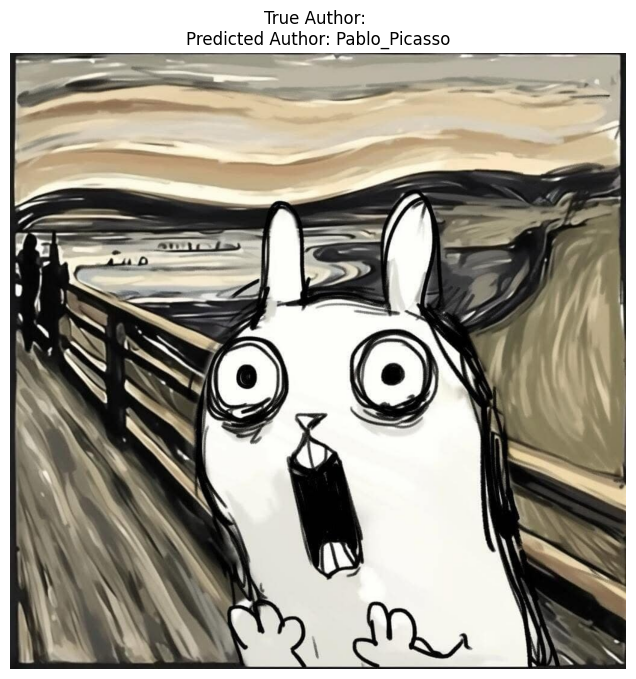

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2 as cv
import tensorflow as tf

def predict_author_voting(img_path):
    # 讀取與預處理圖片
    img = Image.open(img_path).convert("RGB")
    img = img.resize(MODEL_IMG_SIZE)
    img_array = np.array(img) / 255.0  # 正規化
    img_tensor = tf.expand_dims(img_array, axis=0)  # 增加 batch 維度

    # 所有模型預測
    preds_list = []
    for i, model in enumerate(models_arr):
        pred = model.predict(img_tensor, verbose=0)
        preds_list.append(pred)

    # 權重平均
    preds_list = np.array(preds_list)
    weights = np.array([model_weights.get(i, 1.0) for i in range(len(models_arr))])
    weighted_pred = np.average(preds_list, axis=0, weights=weights)

    pred_label = np.argmax(weighted_pred)
    pred_author = rev_class_name[pred_label]
    return pred_author

# 單張測試圖
test_path = "C:/YvesProject/中央/AI作業/036163c2-cedc-4f8c-ac9d-4df87d187706.jpg"

plt.figure(figsize=(8, 8))

try:
    img = Image.open(test_path)
    img = np.array(img)  # 轉成 NumPy 陣列
    img = cv.cvtColor(img, cv.COLOR_RGB2BGR)  # 轉成 OpenCV 格式（可選）
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # 顯示用轉回 RGB
except Exception as e:
    print(f"❌ 無法讀取圖檔 {test_path}，錯誤訊息: {e}")
    raise e

plt.imshow(img)
plt.axis("off")

# 預測與真實作者
img_name = os.path.basename(test_path)
true_author = "_".join(img_name.split("_")[:-1])
pred_author = predict_author_voting(test_path)

plt.title(f"True Author: {true_author}\nPredicted Author: {pred_author}", fontsize=12)
plt.show()